In [1]:
# 1. IMPORT LIBRARIES & DATASET LOADING
# --------------------------------------

import json
import os
import re
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union, List, Dict, Any

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

# Displaying options and random seed
pd.set_option("display.max_colwidth", 150)
np.random.seed(42)

# Creating directories
ARTIFACT_ROOT = (Path("/kaggle/working/streamintel360_artifacts")/ "notebook_05_nlp_sentiment")
MODELS_DIR = ARTIFACT_ROOT / "models"
PREPROCESSORS_DIR = ARTIFACT_ROOT / "preprocessors"
REPORTS_DIR = ARTIFACT_ROOT / "reports"
METRICS_DIR = ARTIFACT_ROOT / "metrics"
METADATA_DIR = ARTIFACT_ROOT / "metadata"
FIGURES_DIR = ARTIFACT_ROOT / "figures"

for directory in [ARTIFACT_ROOT,MODELS_DIR,PREPROCESSORS_DIR,REPORTS_DIR,METRICS_DIR,METADATA_DIR,FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Notebook 06 Directories Initialized:")
print(f"  Artifact Root      : {ARTIFACT_ROOT}")
print(f"  Models Directory   : {MODELS_DIR}")
print(f"  Preprocessors      : {PREPROCESSORS_DIR}")
print(f"  Reports Directory  : {REPORTS_DIR}")
print(f"  Metrics Directory  : {METRICS_DIR}")
print(f"  Metadata Directory : {METADATA_DIR}")
print(f"  Figures Directory  : {FIGURES_DIR}")

# Fig saving function
def save_fig(fig_name):
    file_path = FIGURES_DIR / f"{fig_name}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"Figure Saved: {file_path}")


nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Datast path
kaggle_data_path = Path("/kaggle/input/datasets/hamaz911/imdb-dataset-csv/IMDB Dataset.csv")
local_data_path = Path("data/IMDB Dataset.csv")

if kaggle_data_path.exists():
    DATA_PATH = kaggle_data_path
elif local_data_path.exists():
    DATA_PATH = local_data_path
else:
    raise FileNotFoundError(
        f"Could not locate 'IMDB Dataset.csv' at "
        f"{kaggle_data_path} or {local_data_path}."
    )

print(f"\nLoading IMDb 50K Movie Reviews dataset from: {DATA_PATH}")

df_reviews = pd.read_csv(DATA_PATH)

print("\nDataset Loaded Successfully!")
print(f"Total Rows    : {df_reviews.shape[0]:,}")
print(f"Total Columns : {df_reviews.shape[1]}")
print(f"Columns       : {df_reviews.columns.tolist()}")
print("\nTarget Class Distribution:")
print(df_reviews["sentiment"].value_counts())

display(df_reviews.head(3))

Notebook 06 Directories Initialized:
  Artifact Root      : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment
  Models Directory   : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models
  Vectorizers        : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/vectorizers
  Reports Directory  : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports
  Metrics Directory  : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metrics
  Metadata Directory : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metadata
  Figures Directory  : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures

Loading IMDb 50K Movie Reviews dataset from: /kaggle/input/datasets/hamaz911/imdb-dataset-csv/IMDB Dataset.csv

Dataset Loaded Successfully!
Total Rows    : 50,000
Total Columns : 2
Columns       : ['review', 'sentiment']

Target Class Distribution:
sentiment
positive    

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive


In [2]:
# 2. DATA CLEANING AND PREPROCESSING
# --------------------------------------

# Initializing lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Preserving sentiment-critical negation words
negation_words = {"no","nor","not","never","neither","none","nothing","nowhere","hardly","scarcely","barely"}

# Custom stopword set excluding negations
sentiment_stop_words = stop_words - negation_words

# Text cleaning
def clean_review_text(text):
    # Removing HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Converting text to lowercase
    text = text.lower()
    # Expanding sentiment-important contractions
    contractions = {
        "isn't": "is not",
        "wasn't": "was not",
        "weren't": "were not",
        "aren't": "are not",
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "can't": "can not",
        "couldn't": "could not",
        "wouldn't": "would not",
        "shouldn't": "should not",
        "won't": "will not",
        "haven't": "have not",
        "hasn't": "has not",
        "hadn't": "had not",
        "mustn't": "must not",
        "mightn't": "might not"
    }

    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    # Removing URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Keeping only alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)
    # Tokenizing, removing neutral stopwords,
    # lemmatizing, and preserving negations
    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in sentiment_stop_words
        and (word in negation_words or len(word) > 2)
    ]
    return " ".join(tokens)

# Preprocessing
start_time = time.time()
print("Starting sentiment-aware text preprocessing...")

df_reviews["cleaned_review"] = [clean_review_text(review) for review in df_reviews["review"]]
# Encoding sentiment labels
df_reviews["sentiment_label"] = df_reviews["sentiment"].map(
    {"positive": 1,"negative": 0})

elapsed_time = time.time() - start_time
print(f"\nData Cleaning completed in {elapsed_time:.2f} seconds")

# Saving data
cleaned_parquet_path = ARTIFACT_ROOT / "cleaned_imdb_reviews.parquet"
cleaned_csv_path = ARTIFACT_ROOT / "cleaned_imdb_reviews.csv"

df_reviews.to_parquet(cleaned_parquet_path, index=False)
df_reviews.to_csv(cleaned_csv_path, index=False)

print(f"Saved preprocessed dataset to: {cleaned_parquet_path}")
print(f"Saved preprocessed CSV to      : {cleaned_csv_path}")

print("\nRAW REVIEW SAMPLE:")
print(df_reviews["review"].iloc[0][:300])

print("\nCLEANED REVIEW SAMPLE:")
print(df_reviews["cleaned_review"].iloc[0][:300])

print("\nENCODED TARGET DISTRIBUTION:")
print(df_reviews["sentiment_label"].value_counts())

empty_reviews = (df_reviews["cleaned_review"].str.strip() == "").sum()
print(f"\nEMPTY CLEANED REVIEWS: {empty_reviews}")
print("\nMISSING VALUES:")
print(
    df_reviews[["review", "cleaned_review", "sentiment_label"]].isnull().sum())

Starting sentiment-aware text preprocessing...

Data Cleaning completed in 28.65 seconds
Saved preprocessed dataset to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/cleaned_imdb_reviews.parquet
Saved preprocessed CSV to      : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/cleaned_imdb_reviews.csv

RAW REVIEW SAMPLE:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

CLEANED REVIEW SAMPLE:
one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust not show faint hearted timid show pull no punch regard drug sex violence hardcore classic use word called nickname given oswald maximum security state pe

ENCODED TARG

                           DATASET OVERVIEW & SUMMARY                           
Total Reviews          : 50,000
Positive Reviews (1)   : 25,000
Negative Reviews (0)   : 25,000

RAW REVIEW WORD COUNT STATISTICS:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.46,164.95,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.85,177.50,10.0,125.0,172.0,284.0,2470.0



CLEANED REVIEW WORD COUNT STATISTICS:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,118.46,86.18,3.0,65.0,89.0,144.0,833.0
positive,25000.0,121.05,94.09,7.0,63.0,89.0,148.0,1404.0


Saved EDA summary statistics to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/eda_text_statistics.csv
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/sentiment_class_distribution.png


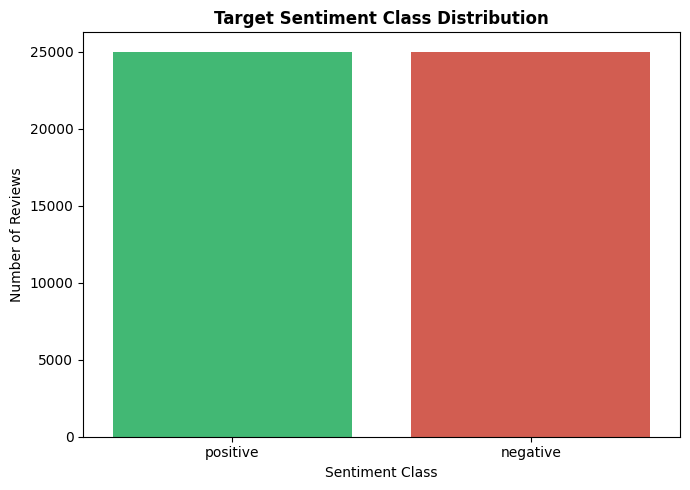

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/word_count_distribution_by_sentiment.png


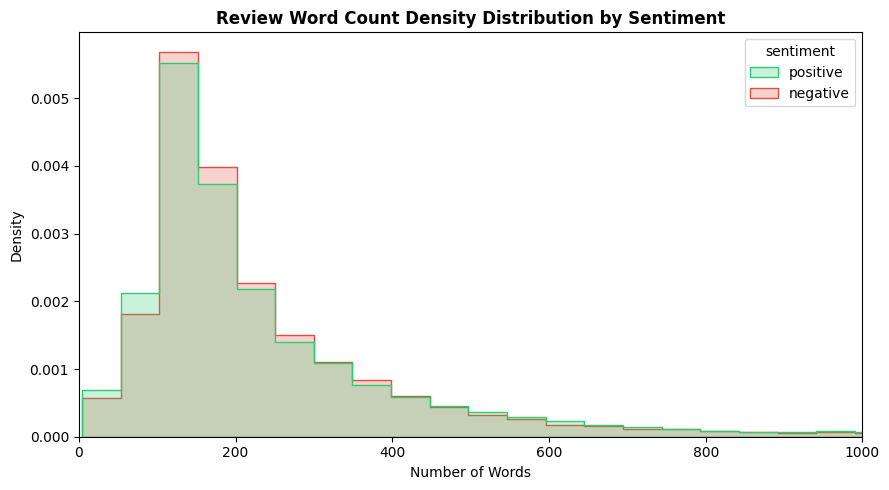

In [3]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------

# Raw vs. Cleaned text feature calculation
df_reviews['review_length'] = df_reviews['review'].str.len()
df_reviews['word_count'] = df_reviews['review'].str.split().str.len()
df_reviews['cleaned_word_count'] = df_reviews['cleaned_review'].str.split().str.len()

print("                           DATASET OVERVIEW & SUMMARY                           ")
print(f"Total Reviews          : {len(df_reviews):,}")
print(f"Positive Reviews (1)   : {(df_reviews['sentiment_label'] == 1).sum():,}")
print(f"Negative Reviews (0)   : {(df_reviews['sentiment_label'] == 0).sum():,}")

# Statistics Tables
raw_wc_stats = df_reviews.groupby('sentiment')['word_count'].describe().round(2)
clean_wc_stats = df_reviews.groupby('sentiment')['cleaned_word_count'].describe().round(2)

print("\nRAW REVIEW WORD COUNT STATISTICS:")
display(raw_wc_stats)

print("\nCLEANED REVIEW WORD COUNT STATISTICS:")
display(clean_wc_stats)

# Saving summary stats as artifact
eda_stats_path = REPORTS_DIR / "eda_text_statistics.csv"
stats_summary = pd.concat([raw_wc_stats.add_prefix("raw_"), clean_wc_stats.add_prefix("clean_")], axis=1)
stats_summary.to_csv(eda_stats_path)
print(f"Saved EDA summary statistics to: {eda_stats_path}")

# PLOT 1: Target Class Distribution Plot
plt.figure(figsize=(7, 5))
sns.countplot(data=df_reviews, x='sentiment', hue='sentiment', palette={'negative': '#e74c3c', 
                                                                        'positive': '#2ecc71'}, legend=False)
plt.title('Target Sentiment Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=10)
plt.ylabel('Number of Reviews', fontsize=10)
plt.tight_layout()
save_fig("sentiment_class_distribution")
plt.show()
plt.close()

# PLOT 2: Word Count Distribution Plot by Sentiment
plt.figure(figsize=(9, 5))
sns.histplot(data=df_reviews, x='word_count', hue='sentiment', bins=50, element='step', stat='density', common_norm=False,
    palette={'negative': '#e74c3c', 'positive': '#2ecc71'}
)
plt.title('Review Word Count Density Distribution by Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Number of Words', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.xlim(0, 1000)
plt.tight_layout()
save_fig("word_count_distribution_by_sentiment")
plt.show()
plt.close()

In [4]:
# 4. NLP FEATURE PREPARATION & NEGATION VERIFICATION
# ----------------------------------------------------

print("NLP PREPROCESSING & STOPWORDS AUDIT")
print(f"Original NLTK Stopwords Count : {len(stop_words)}")
print(f"Custom Sentiment Stopwords    : {len(sentiment_stop_words)}")
print(
    f"Preserved Negation Words "
    f"({len(negation_words)}): {sorted(negation_words)}"
)

# NEGATION PRESERVATION TEST
sample_texts = [
    "This movie was not good and I never liked it at all, no way!",
    "This movie isn't good.",
    "I didn't enjoy this film.",
    "The acting wasn't bad.",
    "I really liked this movie."
]

print("\nNEGATION PRESERVATION DEMO:")
for text in sample_texts:
    processed_text = clean_review_text(text)
    print(f"\nRaw Input : {text}")
    print(f"Processed : {processed_text}")

print("\nDATASET SAMPLE CHECK:")
print("Cleaned Sample (First Review):")
print(f"  {df_reviews['cleaned_review'].iloc[0][:250]}.....")

print("\nPREPROCESSING VALIDATION:")
assert "not" in clean_review_text("This movie is not good.").split()
assert "never" in clean_review_text("I never liked this movie.").split()
assert "not" in clean_review_text("I didn't like this movie.").split()
assert "not" in clean_review_text("This movie isn't good.").split()
print("Negation preservation checks passed.")

NLP PREPROCESSING & STOPWORDS AUDIT
Original NLTK Stopwords Count : 198
Custom Sentiment Stopwords    : 195
Preserved Negation Words (11): ['barely', 'hardly', 'neither', 'never', 'no', 'none', 'nor', 'not', 'nothing', 'nowhere', 'scarcely']

NEGATION PRESERVATION DEMO:

Raw Input : This movie was not good and I never liked it at all, no way!
Processed : movie not good never liked no way

Raw Input : This movie isn't good.
Processed : movie not good

Raw Input : I didn't enjoy this film.
Processed : not enjoy film

Raw Input : The acting wasn't bad.
Processed : acting not bad

Raw Input : I really liked this movie.
Processed : really liked movie

DATASET SAMPLE CHECK:
Cleaned Sample (First Review):
  one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust not show faint hearted timid show pull no punch regard drug sex violence hardcore classic use word call.....

PREPROCESSING VALIDATION:
Negatio

In [5]:
# 5. TRAIN/TEST SPLIT & TF-IDF FEATURE ENGINEERING
# --------------------------------------------------

# Features and target initialization
X = df_reviews["cleaned_review"]
y = df_reviews["sentiment_label"]

# STRATIFIED TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("TRAIN/TEST SPLIT & TF-IDF VECTORIZATION")
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

print("\nTraining Class Distribution:")
print(y_train.value_counts().rename(
        {1: "Positive (1)",0: "Negative (0)"}))

print("\nTesting Class Distribution:")
print(y_test.value_counts().rename(
        {1: "Positive (1)",0: "Negative (0)"}))

# TF-IDF FEATURE EXTRACTION
tfidf_vectorizer = TfidfVectorizer(
    max_features=50_000, ngram_range=(1, 2),min_df=2,max_df=0.95,sublinear_tf=True)
print("\nFitting TF-IDF vectorizer on training set...")
start_time = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
elapsed_time = time.time() - start_time

# NOTE: the fitted vectorizer is saved once, in the final production
# export step (Section 11) -- avoids writing it to disk twice under
# two different filenames in one run.
print(
    f"\nTF-IDF feature engineering completed "
    f"in {elapsed_time:.2f} seconds"
)
print(f"Training matrix shape : {X_train_tfidf.shape}")
print(f"Testing matrix shape  : {X_test_tfidf.shape}")
print(
    f"Vocabulary size       : "
    f"{len(tfidf_vectorizer.vocabulary_):,}"
)

# SAMPLE VOCABULARY INSPECTION
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nSample Indexed Features (Unigrams & Bigrams):")
sample_features = feature_names[::5000].tolist()
print(sample_features)

TRAIN/TEST SPLIT & TF-IDF VECTORIZATION
Training samples : 40,000
Testing samples  : 10,000

Training Class Distribution:
sentiment_label
Positive (1)    20000
Negative (0)    20000
Name: count, dtype: int64

Testing Class Distribution:
sentiment_label
Negative (0)    5000
Positive (1)    5000
Name: count, dtype: int64

Fitting TF-IDF vectorizer on training set...

TF-IDF feature engineering completed in 19.23 seconds
Saved fitted TF-IDF vectorizer to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/vectorizers/streamintel_sentiment_tfidf.joblib
Training matrix shape : (40000, 50000)
Testing matrix shape  : (10000, 50000)
Vocabulary size       : 50,000

Sample Indexed Features (Unigrams & Bigrams):
['aag', 'brave enough', 'deter', 'film simple', 'hour', 'loyalist', 'not alive', 'pudding', 'show sign', 'title film']


RUNNING NLP MODEL TRAINING & BENCHMARK

Training Multinomial Naive Bayes.....
Saved model artifact to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/multinomial_naive_bayes.joblib

Training Logistic Regression.....
Saved model artifact to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/logistic_regression.joblib

Training Linear SVC.....
Saved model artifact to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/linear_svc.joblib

BENCHMARK COMPLETED SUCCESSFULLY
Saved benchmark CSV to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/nlp_model_benchmark.csv
Saved metrics CSV to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metrics/nlp_model_benchmark.csv
Top Model Selected: Linear SVC (F1: 0.9120)
Saved model metadata to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metadata/best_nlp_model.json


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,Linear SVC,0.9118,0.9095,0.9146,0.9120,0.9695,0.72
1,Logistic Regression,0.9084,0.9010,0.9176,0.9092,0.9682,0.76
2,Multinomial Naive Bayes,0.8849,0.8800,0.8914,0.8856,0.9534,0.04


Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/nlp_model_benchmark_comparison.png


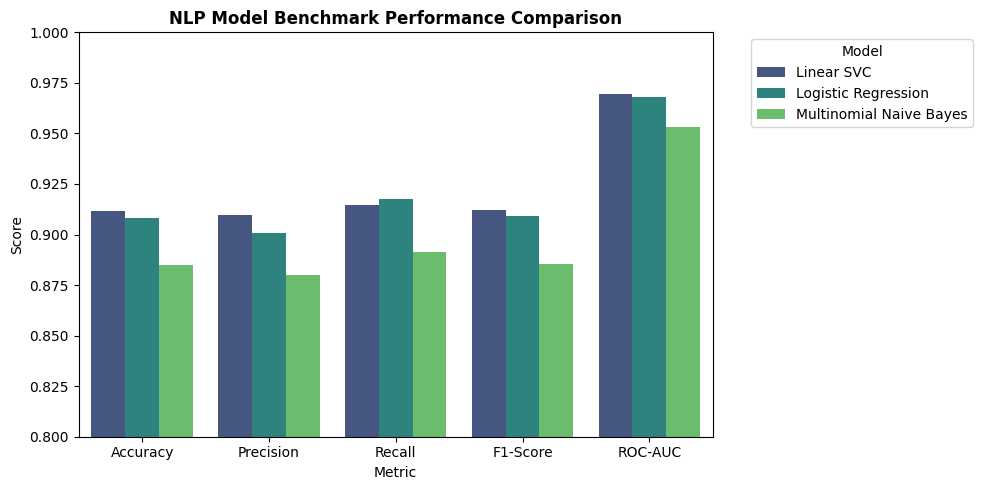

In [6]:
# 6. MULTI-MODEL COMPARISON & ARTIFACT PERSISTENCE
# --------------------------------------------------

# Defining baseline models
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Linear SVC": LinearSVC(random_state=42,max_iter=2000)}

results = []
trained_models = {}
prediction_scores = {}

print("RUNNING NLP MODEL TRAINING & BENCHMARK")

# MODEL TRAINING & EVALUATION
for name, model in models.items():
    print(f"\nTraining {name}.....")
    start_time = time.time()
    
    # Train model
    model.fit(X_train_tfidf,y_train)
    train_time = time.time() - start_time
    # Predictions
    y_pred = model.predict(X_test_tfidf)
    # Classification metrics
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    # ROC-AUC SCORE
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]

    else:
        y_score = model.decision_function(X_test_tfidf)
    roc_auc = roc_auc_score(y_test,y_score)

    # MODEL ARTIFACT
    model_slug = (name.lower().replace(" ", "_"))
    model_path = (MODELS_DIR /f"{model_slug}.joblib")
    joblib.dump(model,model_path)
    print(f"Saved model artifact to: "f"{model_path}")

    # PREDICTION ARTIFACTS
    prediction_scores[model_slug] = {"y_pred": y_pred,"y_score": y_score}
    np.save(METRICS_DIR /f"{model_slug}_y_pred.npy",y_pred)
    np.save(METRICS_DIR /f"{model_slug}_y_score.npy",y_score)

    # STORE MODEL RESULTS
    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "Train Time (s)": round(train_time, 2)
    })
    trained_models[name] = model

# CREATE BENCHMARK TABLE
df_benchmark = (
    pd.DataFrame(results).sort_values(by="F1-Score",ascending=False).reset_index(drop=True))
benchmark_csv_path = (REPORTS_DIR /"nlp_model_benchmark.csv")
df_benchmark.to_csv(benchmark_csv_path,index=False)

# Also save benchmark to metrics directory
benchmark_metrics_path = (METRICS_DIR /"nlp_model_benchmark.csv")
df_benchmark.to_csv(benchmark_metrics_path,index=False)

# BEST MODEL SELECTION
best_model_row = df_benchmark.iloc[0]
best_model_name = best_model_row["Model"]
best_model_slug = (best_model_name.lower().replace(" ", "_"))
best_model_meta = {
    "best_model_name": best_model_name,
    "best_model_slug": best_model_slug,
    "selection_metric": "F1-Score",
    "f1_score": float(best_model_row["F1-Score"]),
    "accuracy": float(best_model_row["Accuracy"]),
    "precision": float(best_model_row["Precision"]),
    "recall": float(best_model_row["Recall"]),
    "roc_auc": float(best_model_row["ROC-AUC"]),
    "train_time_seconds": float(
        best_model_row["Train Time (s)"]
    ),
    "model_artifact": str(
        MODELS_DIR /
        f"{best_model_slug}.joblib"
    ),
    "vectorizer_artifact": str(
        PREPROCESSORS_DIR /
        "streamintel_sentiment_tfidf.joblib"
    )
}

# SAVE BEST MODEL METADATA
best_model_metadata_path = (METADATA_DIR /"best_nlp_model.json")
with open(
    best_model_metadata_path,
    "w"
) as f:
    json.dump(best_model_meta,f,indent=4)

# BENCHMARK OUTPUT
print( "\nBENCHMARK COMPLETED SUCCESSFULLY")
print(f"Saved benchmark CSV to: "f"{benchmark_csv_path}")
print(f"Saved metrics CSV to: "f"{benchmark_metrics_path}")
print(
    f"Top Model Selected: "
    f"{best_model_name} "
    f"(F1: {best_model_meta['f1_score']:.4f})"
)
print(
    f"Saved model metadata to: "
    f"{best_model_metadata_path}"
)
display(df_benchmark)

# BENCHMARK COMPARISON VISUALIZATION
plt.figure(figsize=(10, 5))
df_melted = df_benchmark.melt(
    id_vars="Model",
    value_vars=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)
sns.barplot(data=df_melted,x="Metric",y="Score",hue="Model",palette="viridis")
plt.title("NLP Model Benchmark Performance Comparison",fontsize=12,fontweight="bold")
plt.ylim(0.80,1.0)
plt.ylabel("Score",fontsize=10)
plt.xlabel("Metric",fontsize=10)
plt.legend(title="Model",bbox_to_anchor=(1.05, 1),loc="upper left")
plt.tight_layout()
save_fig("nlp_model_benchmark_comparison")
plt.show()
plt.close()

             INITIAL MODEL PERFORMANCE (LOGISTIC REGRESSION C=1.5)              
Accuracy : 0.9102
F1 Score : 0.9108
ROC-AUC  : 0.9697

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative     0.9162    0.9030    0.9095      5000
    Positive     0.9044    0.9174    0.9108      5000

    accuracy                         0.9102     10000
   macro avg     0.9103    0.9102    0.9102     10000
weighted avg     0.9103    0.9102    0.9102     10000

Saved tuned model to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/logistic_regression_tuned.joblib
Saved evaluation metrics to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metrics/initial_model_eval.json
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/initial_model_confusion_matrix.png


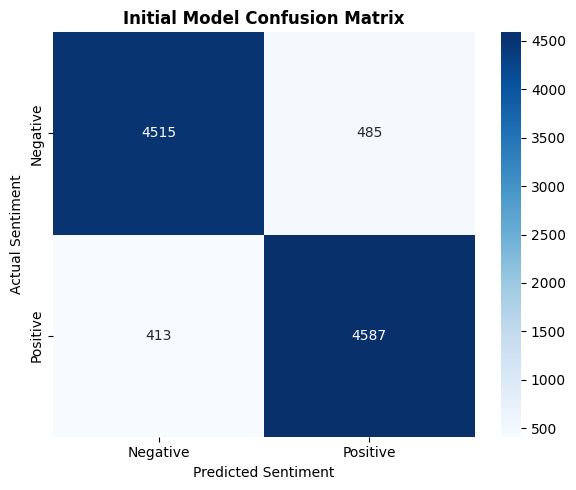

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/top_sentiment_features.png


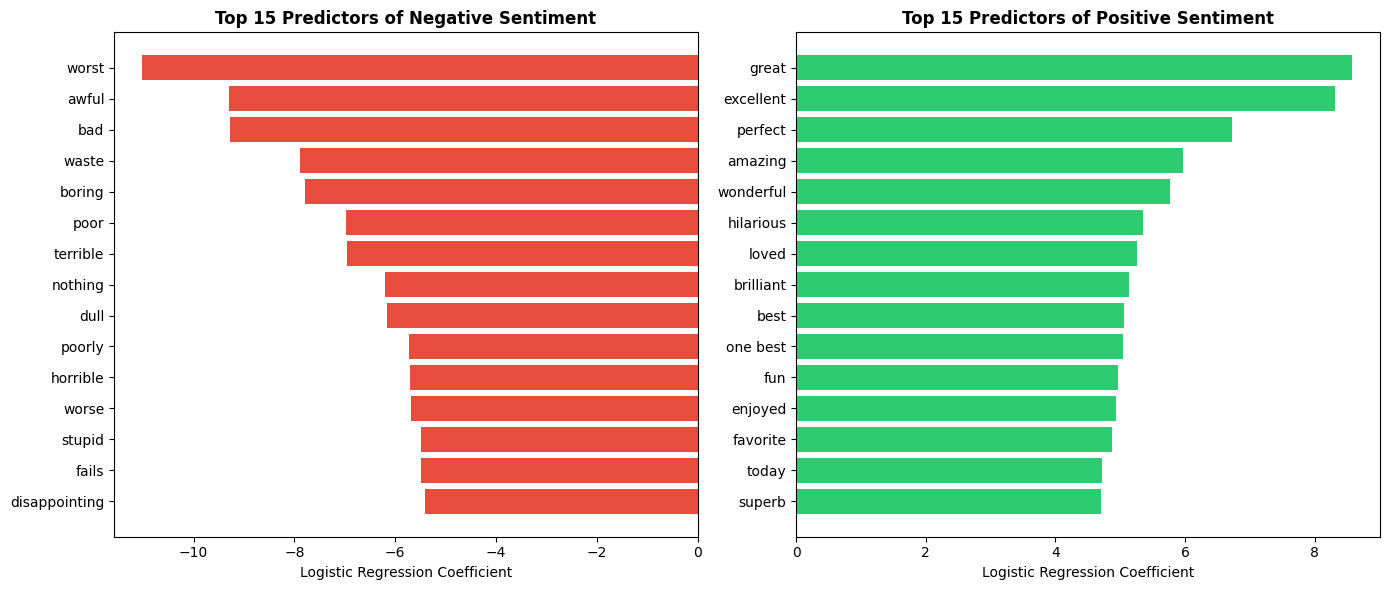

In [7]:
# 7. INITIAL MODEL EVALUATION & FEATURE WEIGHTS
# -----------------------------------------------

# Model training & evaluation (c=1.5 regularization)
benchmark_model = LogisticRegression(C=1.5, max_iter=1000, random_state=42)
benchmark_model.fit(X_train_tfidf, y_train)

# Generating predictions and probabilities
y_pred = benchmark_model.predict(X_test_tfidf)
y_prob = benchmark_model.predict_proba(X_test_tfidf)[:, 1]

# Calculating baseline performance metrics
benchmark_accuracy = accuracy_score(y_test, y_pred)
benchmark_f1 = f1_score(y_test, y_pred)
benchmark_roc_auc = roc_auc_score(y_test, y_prob)

print("             INITIAL MODEL PERFORMANCE (LOGISTIC REGRESSION C=1.5)              ")
print(f"Accuracy : {benchmark_accuracy:.4f}")
print(f"F1 Score : {benchmark_f1:.4f}")
print(f"ROC-AUC  : {benchmark_roc_auc:.4f}")

print("\nCLASSIFICATION REPORT:")
clf_report_text = classification_report(y_test, y_pred, target_names=["Negative", "Positive"], digits=4)
clf_report_dict = classification_report(y_test, y_pred, target_names=["Negative", "Positive"], output_dict=True)
print(clf_report_text)

# Saving model
model_save_path = MODELS_DIR / "logistic_regression_tuned.joblib"
joblib.dump(benchmark_model, model_save_path)

eval_metrics = {
    "model_name": "Logistic Regression (C=1.5)",
    "model_type": "LogisticRegression",
    "regularization_C": 1.5,
    "accuracy": round(benchmark_accuracy, 4),
    "f1_score": round(benchmark_f1, 4),
    "roc_auc": round(benchmark_roc_auc, 4),
    "classification_report": clf_report_dict,
    "model_artifact": str(model_save_path),
    "vectorizer_artifact": str(PREPROCESSORS_DIR / "streamintel_sentiment_tfidf.joblib")
}

metrics_save_path = METRICS_DIR / "initial_model_eval.json"
with open(metrics_save_path, "w") as f:
    json.dump(eval_metrics, f, indent=4)

print(f"Saved tuned model to: {model_save_path}")
print(f"Saved evaluation metrics to: {metrics_save_path}")


# Plot 1: CM Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
    xticklabels=["Negative", "Positive"],yticklabels=["Negative", "Positive"])
plt.title("Initial Model Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Sentiment", fontsize=10)
plt.ylabel("Actual Sentiment", fontsize=10)
plt.tight_layout()
save_fig("initial_model_confusion_matrix")
plt.show()
plt.close()

# Plot 2: Top Positive & Negative Feature Weight
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefs = benchmark_model.coef_[0]

# Extracting top 15 negative and top 15 positive features (properly ordered)
top_neg_idx = np.argsort(coefs)[:15]
top_pos_idx = np.argsort(coefs)[-15:][::-1]  # Reverse to show highest on top
plt.figure(figsize=(14, 6))

# Subplot 1: Top 15 Negative Sentiment Predictors
plt.subplot(1, 2, 1)
plt.barh(feature_names[top_neg_idx], coefs[top_neg_idx], color="#e74c3c")
plt.title("Top 15 Predictors of Negative Sentiment", fontsize=12, fontweight="bold")
plt.xlabel("Logistic Regression Coefficient", fontsize=10)
plt.gca().invert_yaxis()

# Subplot 2: Top 15 Positive Sentiment Predictors
plt.subplot(1, 2, 2)
plt.barh(feature_names[top_pos_idx], coefs[top_pos_idx], color="#2ecc71")
plt.title("Top 15 Predictors of Positive Sentiment", fontsize=12, fontweight="bold")
plt.xlabel("Logistic Regression Coefficient", fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig("top_sentiment_features")
plt.show()
plt.close()

In [8]:
# 8. LOGISTIC REGRESSION HYPERPARAMETER OPTIMIZATION
# ---------------------------------------------------

# Candidate regularization values
C_values = [0.5, 1.0, 1.5, 2.0]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
tuning_results = []

print("             LOGISTIC REGRESSION HYPERPARAMETER OPTIMIZATION (3-FOLD CV)        ")
for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    start_time = time.time()
    
    # 3-Fold Cross-Validation on F1-Score
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring="f1", n_jobs=-1)
    elapsed_time = time.time() - start_time
    
    tuning_results.append({
        "C": C,
        "Mean F1": round(scores.mean(), 4),
        "Std F1": round(scores.std(), 4),
        "Time (s)": round(elapsed_time, 2)
    })
    print(f"  C={C:<3} --> Mean F1: {scores.mean():.4f} (±{scores.std():.4f}) | Time: {elapsed_time:.2f}s")

# Results summary table
df_tuning = (pd.DataFrame(tuning_results)
             .sort_values("Mean F1", ascending=False)
             .reset_index(drop=True))

# Saving tuning report
tuning_csv_path = METRICS_DIR / "lr_hyperparameter_tuning.csv"
df_tuning.to_csv(tuning_csv_path, index=False)

# Selecting best C parameter for Cell 9
best_C = float(df_tuning.loc[0, "C"])
best_cv_f1 = float(df_tuning.loc[0, "Mean F1"])

# Saving tuning metadata
tuning_metadata = {
    "parameter_tuned": "C",
    "candidate_values": C_values,
    "cross_validation": "StratifiedKFold",
    "n_splits": 3,
    "shuffle": True,
    "random_state": 42,
    "scoring_metric": "f1",
    "best_C": best_C,
    "best_cv_f1": best_cv_f1
}

tuning_metadata_path = METADATA_DIR / "lr_hyperparameter_tuning.json"
with open(tuning_metadata_path, "w") as f:
    json.dump(tuning_metadata, f, indent=4)

print(f"✓ Tuning Completed. Selected Optimal Parameter: C = {best_C}")
print(f"✓ Best Cross-Validation F1-Score: {best_cv_f1:.4f}")
print(f"✓ Saved hyperparameter search report to: {tuning_csv_path}")
print(f"✓ Saved tuning metadata to: {tuning_metadata_path}")
display(df_tuning)

             LOGISTIC REGRESSION HYPERPARAMETER OPTIMIZATION (3-FOLD CV)        
  C=0.5 --> Mean F1: 0.8945 (±0.0010) | Time: 2.83s
  C=1.0 --> Mean F1: 0.9006 (±0.0023) | Time: 1.64s
  C=1.5 --> Mean F1: 0.9021 (±0.0014) | Time: 0.68s
  C=2.0 --> Mean F1: 0.9033 (±0.0007) | Time: 0.69s
✓ Tuning Completed. Selected Optimal Parameter: C = 2.0
✓ Best Cross-Validation F1-Score: 0.9033
✓ Saved hyperparameter search report to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metrics/lr_hyperparameter_tuning.csv
✓ Saved tuning metadata to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metadata/lr_hyperparameter_tuning.json


,C,Mean F1,Std F1,Time (s)
0,2.0,0.9033,0.0007,0.69
1,1.5,0.9021,0.0014,0.68
2,1.0,0.9006,0.0023,1.64
3,0.5,0.8945,0.0010,2.83


       TRAINING FINAL PRODUCTION MODEL (LOGISTIC REGRESSION C=2.0)         
Training completed in 1.14 seconds

FINAL TEST PERFORMANCE:
Accuracy  : 0.9113
Precision : 0.9060
Recall    : 0.9178
F1 Score  : 0.9119
ROC-AUC   : 0.9705

FINAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative     0.9167    0.9048    0.9107      5000
    Positive     0.9060    0.9178    0.9119      5000

    accuracy                         0.9113     10000
   macro avg     0.9114    0.9113    0.9113     10000
weighted avg     0.9114    0.9113    0.9113     10000

Saved final model artifact to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/final_sentiment_model.joblib
Saved final evaluation JSON to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/metrics/final_model_eval.json
Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/final_model_eval_plots.png


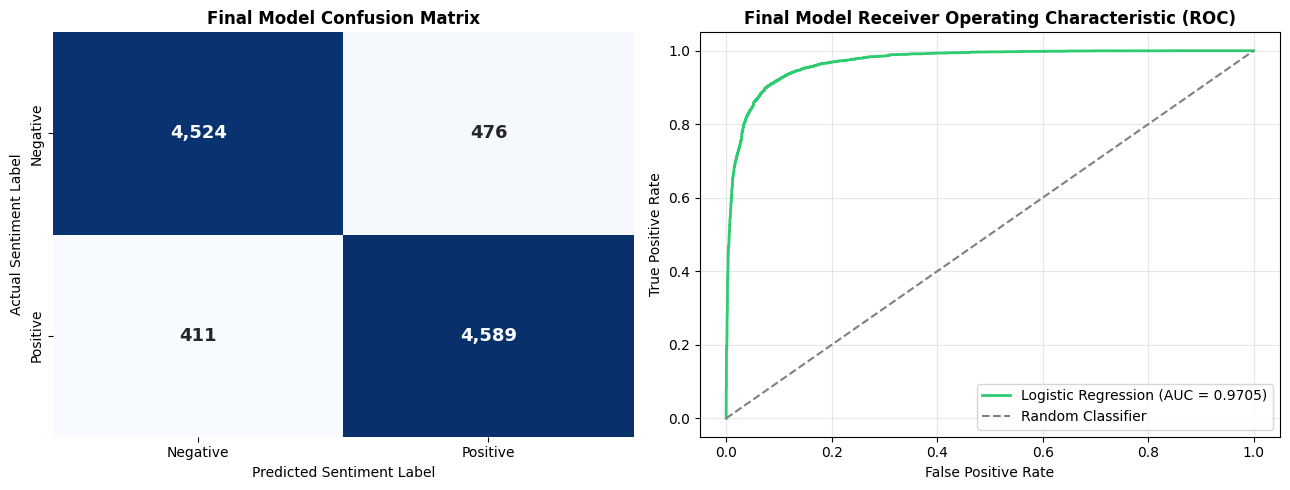

In [9]:
# 9. FINAL MODEL RETRAINING & TEST EVALUATION
# ---------------------------------------------
print(f"       TRAINING FINAL PRODUCTION MODEL (LOGISTIC REGRESSION C={best_C})         ")

final_sentiment_model = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
start_time = time.time()
final_sentiment_model.fit(X_train_tfidf, y_train)
final_training_time = time.time() - start_time

# Generating predictions and evaluating metrices
y_test_pred = final_sentiment_model.predict(X_test_tfidf)
y_test_prob = final_sentiment_model.predict_proba(X_test_tfidf)[:, 1]

final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)
final_roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Training completed in {final_training_time:.2f} seconds\n")
print("FINAL TEST PERFORMANCE:")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nFINAL CLASSIFICATION REPORT:")
clf_report_text = classification_report(y_test, y_test_pred, target_names=["Negative", "Positive"], digits=4)
clf_report_dict = classification_report(y_test, y_test_pred, target_names=["Negative", "Positive"], output_dict=True)
print(clf_report_text)

# Saving artifacts
final_model_path = MODELS_DIR / "final_sentiment_model.joblib"
joblib.dump(final_sentiment_model, final_model_path)

final_eval_meta = {
    "model_type": "Logistic Regression",
    "model_name": "Final Sentiment Model",
    "best_C": best_C,
    "training_time_seconds": round(final_training_time, 2),
    "accuracy": round(final_accuracy, 4),
    "precision": round(final_precision, 4),
    "recall": round(final_recall, 4),
    "f1_score": round(final_f1, 4),
    "roc_auc": round(final_roc_auc, 4),
    "classification_report": clf_report_dict,
    "model_artifact": str(final_model_path),
    "vectorizer_artifact": str(PREPROCESSORS_DIR / "streamintel_sentiment_tfidf.joblib"),
    "hyperparameter_metadata": str(METADATA_DIR / "lr_hyperparameter_tuning.json")
}

final_metrics_path = METRICS_DIR / "final_model_eval.json"
with open(final_metrics_path, "w") as f:
    json.dump(final_eval_meta, f, indent=4)

print(f"Saved final model artifact to: {final_model_path}")
print(f"Saved final evaluation JSON to: {final_metrics_path}")

# Visualizing CM & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    annot_kws={"size": 13, "weight": "bold"},
    ax=axes[0]
)

axes[0].set_title("Final Model Confusion Matrix", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Sentiment Label", fontsize=10)
axes[0].set_ylabel("Actual Sentiment Label", fontsize=10)

# Subplot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color="#2ecc71", lw=2, label=f"Logistic Regression (AUC = {final_roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Random Classifier")
axes[1].set_title("Final Model Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("False Positive Rate", fontsize=10)
axes[1].set_ylabel("True Positive Rate", fontsize=10)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("final_model_eval_plots")
plt.show()
plt.close()

                           ERROR ANALYSIS SUMMARY                               
Total Test Reviews      : 10,000
Correct Predictions     : 9,113
Total Misclassifications: 887 (8.87%)
False Positives (FP)    : 476
False Negatives (FN)    : 411

Saved full misclassifications report to: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/misclassified_reviews.csv
Saved top 10 high-confidence errors to : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/high_confidence_errors.csv

TOP 10 HIGH-CONFIDENCE MISCLASSIFICATIONS:


,actual_sentiment,predicted_sentiment,confidence,review
3157,Negative,Positive,0.9929,sleek sexy movie must see upon multiple viewing one truly understand uniqueness film personally enjoy narrator intelligent no subject left untouched style narration introduction grip right away hold edge seat throughout film provides wonderful insight world trainables allows audience really connect internal horror film exhibit script hold movie together wonderfully not kid elderly alike gain higher understanding trainables modern grasp sexual experience ahead time groundbreaking cinematography surely defines word masterpiece
9982,Positive,Negative,0.9874,okay first got movie christmas present free first movie meant stereoscopic part whenever main character car movie fall flat not hard film car second story not good lot thing wrong third showing death beginning film made movie suck whenever going get killed watch good laugh not waste time buying download something cheap
3906,Negative,Positive,0.9854,major payne film major make life living hell small group boy marine film not really lot offer provides several hilarious moment well worth watch not expect memorable film however expect laugh way film expense people confrontation major payne chubby boy hilarious really remember film except boy wanting revenge major payne not great film probably best watched rainy day need laughter
2037,Positive,Negative,0.9825,flick sterling example state erotic movie bad porn movie without hardcore sex plot one not bad thing involves female lawyer trying prove lover innocent killing wife rest movie however leaf something desired bad acting bad direction bad looking woman bad set bad cinematography bad sound bad sex scene filmmaker learn difference raunchy erotic not even common sense gabriella hall naked love scene dumb
1380,Negative,Positive,0.9765,loved movie first came year old forgotten film existed one day found used copy sale gas station bought could not wait watch film loved kid saw film many year later hit world like film kid watching adult realized film terrible saddest part film everything place make greatest western ever blew costume perfect good actor music score orchestrail score wonderful keep classic spirit old timey lone ranger alive second score series song country music artest like merle haggerd statler brother song like man mask bad funny movie strongest point briliant storyline one best western plot ever fun watch john reid nursed back health fellow ranger ambushed fun see grow new life identity lone ranger concels identity go revenge run get gang responsible killing brother fellow ranger rode unfortunatly good storyline ruined merle haggard narrating everything watching happen love god merle haggard narration statler brother singing corny stupid song like ride little cowboy playing backgound make movie impossible take serious would love see really good producer take script story film right heart silly film great western would descibe film beautiful woman dress ugliest clothing give star year old dont know better might love
5341,Negative,Positive,0.9694,story go something like small town girl katie jessica simpson decides visit boyfriend big city arrives discovers not quite faithful katie end venturing adventure new york filling bike messenger comedic charming mishap ensues fall hole ground thus meet charismatic good guy ben luke wilson not love first sight least destiny ben not give quite easy small town girl blonde couple evil executive building firm decides perfect scapegoat cunning plan misunderstanding hilarious sad consequence follow however one blonde not take lying people judgmental film soon enough proved wrong joke confident fitting story well developed relationship katie ben feel natural put anything godard created shame multi talented jessica simpson surprise strong role could pull simpson really marilyn monroe day even one scene honoring balance perfectly vulnerable whimsy katie really show not judge book cover luke wilson charming

Figure Saved: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/reports/figures/error_confidence_distribution.png


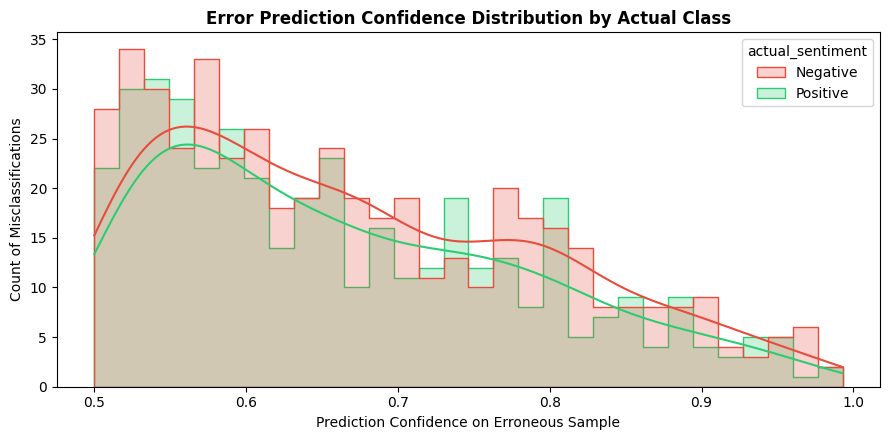

                          QUALITATIVE ERROR INSPECTION                          

TOP FALSE POSITIVE (Actual: Negative | Predicted: Positive | Prob: 0.9929):
"sleek sexy movie must see upon multiple viewing one truly understand uniqueness film personally enjoy narrator intelligent no subject left untouched style narration introduction grip right away hold edge seat throughout film provides wonderful insight world trainables allows audience really connect internal horror film exhibit script hold movie together wonderfully not kid elderly alike gain highe......"


TOP FALSE NEGATIVE (Actual: Positive | Predicted: Negative | Prob: 0.0126):
"okay first got movie christmas present free first movie meant stereoscopic part whenever main character car movie fall flat not hard film car second story not good lot thing wrong third showing death beginning film made movie suck whenever going get killed watch good laugh not waste time buying download something cheap......"



In [10]:
# 10. ERROR ANALYSIS & QUALITATIVE INSPECTION
# ---------------------------------------------

# Creating test evaluation DataFrame
error_analysis = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": y_test_pred,
    "positive_probability": y_test_prob
})

# Mapping target numeric labels to human-readable strings
error_analysis["actual_sentiment"] = error_analysis["actual"].map({0: "Negative", 1: "Positive"})
error_analysis["predicted_sentiment"] = error_analysis["predicted"].map({0: "Negative", 1: "Positive"})

# Identifying misclassified reviews
misclassified = error_analysis[error_analysis["actual"] != error_analysis["predicted"]].copy()

# Calculating prediction confidence score on misclassified reviews
misclassified["confidence"] = np.where(
    misclassified["predicted"] == 1,
    misclassified["positive_probability"],
    1 - misclassified["positive_probability"])

# Separating False Positives and False Negatives
false_positives = misclassified[(misclassified["actual"] == 0) & (misclassified["predicted"] == 1)].copy()
false_negatives = misclassified[(misclassified["actual"] == 1) & (misclassified["predicted"] == 0)].copy()

print("                           ERROR ANALYSIS SUMMARY                               ")
print(f"Total Test Reviews      : {len(error_analysis):,}")
print(f"Correct Predictions     : {(error_analysis['actual'] == error_analysis['predicted']).sum():,}")
print(f"Total Misclassifications: {len(misclassified):,} ({(len(misclassified)/len(error_analysis))*100:.2f}%)")
print(f"False Positives (FP)    : {len(false_positives):,}")
print(f"False Negatives (FN)    : {len(false_negatives):,}")

# Top 10 High Confidence Errors
high_confidence_errors = misclassified.sort_values("confidence", ascending=False).head(10)

# Saving Error Artifacts
misclassified_path = REPORTS_DIR / "misclassified_reviews.csv"
high_conf_path = REPORTS_DIR / "high_confidence_errors.csv"
misclassified.to_csv(misclassified_path, index=False)
high_confidence_errors.to_csv(high_conf_path, index=False)

print(f"\nSaved full misclassifications report to: {misclassified_path}")
print(f"Saved top 10 high-confidence errors to : {high_conf_path}")

print("\nTOP 10 HIGH-CONFIDENCE MISCLASSIFICATIONS:")
display(high_confidence_errors[["actual_sentiment", "predicted_sentiment", "confidence", "review"]].style.format({"confidence": "{:.4f}"}))

# Error confidence distribution plot
plt.figure(figsize=(9, 4.5))
sns.histplot(
    data=misclassified,
    x="confidence",
    hue="actual_sentiment",
    bins=30,
    kde=True,
    palette={"Negative": "#e74c3c", "Positive": "#2ecc71"},
    element="step"
)
plt.title("Error Prediction Confidence Distribution by Actual Class", fontsize=12, fontweight="bold")
plt.xlabel("Prediction Confidence on Erroneous Sample", fontsize=10)
plt.ylabel("Count of Misclassifications", fontsize=10)
plt.tight_layout()
save_fig("error_confidence_distribution")
plt.show()
plt.close()

# Qualitative Error inspection
print("                          QUALITATIVE ERROR INSPECTION                          ")
if not false_positives.empty:
    top_fp = false_positives.sort_values("confidence", ascending=False).iloc[0]
    print(f"\nTOP FALSE POSITIVE (Actual: Negative | Predicted: Positive | Prob: {top_fp['positive_probability']:.4f}):")
    print(f"\"{top_fp['review'][:400]}......\"\n")

if not false_negatives.empty:
    top_fn = false_negatives.sort_values("confidence", ascending=False).iloc[0]
    print(f"\nTOP FALSE NEGATIVE (Actual: Positive | Predicted: Negative | Prob: {top_fn['positive_probability']:.4f}):")
    print(f"\"{top_fn['review'][:400]}......\"\n")

In [11]:
# 11. FINAL ARTIFACT AND METADATA EXPORT
# ----------------------------------------

# Ensuring output directory exists
MODELS_DIR = ARTIFACT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Defining project deployment artifact paths
final_model_path = MODELS_DIR / "streamintel_sentiment_model.joblib"
final_tfidf_path = MODELS_DIR / "streamintel_tfidf_vectorizer.joblib"
metadata_path = MODELS_DIR / "streamintel_sentiment_metadata.json"

# Serializing production model and vectorizer
joblib.dump(final_sentiment_model, final_model_path)
joblib.dump(tfidf_vectorizer, final_tfidf_path)

# Constructing deployment metadata payload
metadata = {
    "project": "STREAMINTEL 360",
    "module": "NLP & Sentiment",
    "task": "Binary Sentiment Classification",
    "dataset": "IMDb 50K Movie Reviews",
    "training_samples": int(len(X_train)),
    "testing_samples": int(len(X_test)),
    "model": "Logistic Regression",
    "regularization_C": float(final_sentiment_model.C),
    "tfidf_features": int(X_train_tfidf.shape[1]),
    "tfidf_vocabulary_size": int(len(tfidf_vectorizer.vocabulary_)),
    "ngram_range": "(1, 2)",
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
    "accuracy": round(float(final_accuracy), 4),
    "precision": round(float(final_precision), 4),
    "recall": round(float(final_recall), 4),
    "f1_score": round(float(final_f1), 4),
    "roc_auc": round(float(final_roc_auc), 4),
    "training_time_seconds": round(float(final_training_time), 2),
    "classes": ["negative", "positive"],
    "decision_threshold": 0.50,
    "model_artifact": str(final_model_path),
    "tfidf_artifact": str(final_tfidf_path),
    "metrics_artifact": str(METRICS_DIR / "final_model_eval.json")
}

# Exporting metadata JSON
with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)

print("             FINAL STREAMINTEL 360 DEPLOYMENT ARTIFACTS EXPORTED               ")
print(f"Model Artifact : {final_model_path} ({final_model_path.stat().st_size / (1024 * 1024):.2f} MB)")
print(f"TF-IDF Vector  : {final_tfidf_path} ({final_tfidf_path.stat().st_size / (1024 * 1024):.2f} MB)")
print(f"Metadata JSON  : {metadata_path} ({metadata_path.stat().st_size / 1024:.2f} KB)")

print("METADATA SUMMARY")
for key, value in metadata.items():
    print(f" --> {key:<23}: {value}")

print("                        RUNNING ARTIFACT RELOAD SMOKE TEST                      ")
loaded_model = joblib.load(final_model_path)
loaded_tfidf = joblib.load(final_tfidf_path)

test_samples = [
    "The cinematography was breathtaking and the plot kept me on the edge of my seat!",
    "Terrible movie. The pacing was painfully slow and the acting felt completely wooden."
]

cleaned_samples = [clean_review_text(sample) for sample in test_samples]
vectorized_samples = loaded_tfidf.transform(cleaned_samples)
predictions = loaded_model.predict(vectorized_samples)
probabilities = loaded_model.predict_proba(vectorized_samples)[:, 1]

for raw, pred, prob in zip(test_samples, predictions, probabilities):
    label = "Positive" if pred == 1 else "Negative"
    print(f"\nReview Text : \"{raw}\"")
    print(f"Prediction  : {label} (Confidence / Prob Positive: {prob:.4f})")

print("\nSmoke Test Passed: Saved artifacts loaded and verified successfully!")

             FINAL STREAMINTEL 360 DEPLOYMENT ARTIFACTS EXPORTED               
Model Artifact : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/streamintel_sentiment_model.joblib (0.38 MB)
TF-IDF Vector  : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/streamintel_tfidf_vectorizer.joblib (1.90 MB)
Metadata JSON  : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models/streamintel_sentiment_metadata.json (1.05 KB)
METADATA SUMMARY
 --> project                : STREAMINTEL 360
 --> module                 : NLP & Sentiment
 --> task                   : Binary Sentiment Classification
 --> dataset                : IMDb 50K Movie Reviews
 --> training_samples       : 40000
 --> testing_samples        : 10000
 --> model                  : Logistic Regression
 --> regularization_C       : 2.0
 --> tfidf_features         : 50000
 --> tfidf_vocabulary_size  : 50000
 --> ngram_range            : (1, 2)
 --> min_df          

In [12]:
# 12. PRODUCTION INFERENCE ENGINE
# ----------------------------------

# Ensuring required NLTK resources are loaded
for resource in ["stopwords", "wordnet"]:
    try:
        nltk.data.find(f"corpora/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)


class StreamIntelSentimentPredictor:
    def __init__(
        self,
        model_path: Union[str, Path] = "models/streamintel_sentiment_model.joblib",
        tfidf_path: Union[str, Path] = "models/streamintel_tfidf_vectorizer.joblib",
        metadata_path: Union[str, Path] = "models/streamintel_sentiment_metadata.json",
    ):
        # Resolving artifact paths with Kaggle / local environment fallbacks
        self.model_path = self._resolve_path(model_path)
        self.tfidf_path = self._resolve_path(tfidf_path)
        self.metadata_path = self._resolve_path(metadata_path)

        # Loading saved production artifacts
        print(f"✓ Initializing StreamIntel Engine from: {self.model_path.parent.resolve()}")
        self.model = joblib.load(self.model_path)
        self.vectorizer = joblib.load(self.tfidf_path)

        with open(self.metadata_path, "r", encoding="utf-8") as f:
            self.metadata = json.load(f)

        # Initializing text preprocessing pipeline
        self.lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words("english"))
        negation_words = {
            "no", "nor", "not", "never", "neither",
            "none", "nothing", "nowhere", "hardly",
            "scarcely", "barely"
        }
        self.negation_words = negation_words
        self.sentiment_stop_words = stop_words - negation_words

    def _resolve_path(self, target_path: Union[str, Path]) -> Path:
        path = Path(target_path)
        if path.exists():
            return path

        # Alternative candidate search paths
        candidates = [
            ARTIFACT_ROOT / path,
            ARTIFACT_ROOT / "models" / path.name,
            Path("/kaggle/working/models") / path.name,
            Path("models") / path.name,
            Path("../models") / path.name,
        ]

        for candidate in candidates:
            if candidate.exists():
                return candidate

        raise FileNotFoundError(
            f"Unable to locate artifact '{path.name}'. Evaluated locations: {[str(p) for p in [path] + candidates]}"
        )

    def preprocess_text(self, text: str) -> str:
        if not isinstance(text, str):
            return ""

        # Remove HTML tags
        text = re.sub(r"<[^>]+>", " ", text)
        # Lowercase text
        text = text.lower()
        # Remove URLs
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        # Keep alphabetic characters
        text = re.sub(r"[^a-z\s]", " ", text)

        # Tokenize, filter sentiment-neutral stopwords, and lemmatize
        tokens = [
            self.lemmatizer.lemmatize(word)
            for word in text.split()
            if word not in self.sentiment_stop_words and (word in self.negation_words or len(word) > 2)
        ]
        return " ".join(tokens)

    def predict(self, reviews: Union[str, List[str]]) -> List[Dict[str, Any]]:
        if isinstance(reviews, str):
            reviews = [reviews]
        if not reviews:
            return []

        start_time = time.time()

        # Preprocess and vectorization batch
        cleaned_texts = [self.preprocess_text(r) for r in reviews]
        features = self.vectorizer.transform(cleaned_texts)

        # Probabilities & Decision Threshold
        probabilities = self.model.predict_proba(features)[:, 1]
        threshold = float(self.metadata.get("decision_threshold", 0.50))
        predictions = (probabilities >= threshold).astype(int)

        total_latency_ms = (time.time() - start_time) * 1000
        per_sample_latency_ms = total_latency_ms / len(reviews)

        # Build response payload
        results = []
        for raw, prob, pred in zip(reviews, probabilities, predictions):
            label = "Positive" if pred == 1 else "Negative"
            confidence = prob if pred == 1 else (1.0 - prob)
            results.append({
                "review": raw,
                "sentiment": label,
                "confidence": round(float(confidence), 4),
                "positive_probability": round(float(prob), 4),
                "latency_ms": round(per_sample_latency_ms, 3)
            })

        return results


# Demonstration and validation block
if __name__ == "__main__":
    predictor = StreamIntelSentimentPredictor()

    sample_reviews = [
        "The plot was completely predictable and the acting was atrocious.",
        "An absolute masterpiece! The visuals and soundtrack blew me away.",
        "Not terrible, but I definitely wouldn't watch it a second time.",
        "I went in expecting trash, but it turned out to be surprisingly touching and well crafted."
    ]

    print("                    STREAMINTEL 360 LIVE INFERENCE RESULTS                      ")
    predictions = predictor.predict(sample_reviews)

    for i, res in enumerate(predictions, 1):
        print(f"\n[{i}] Review Text : \"{res['review']}\"")
        print(f"  ---> Predicted Sentiment : {res['sentiment']}")
        print(f"  ---> Model Confidence    : {res['confidence']:.2%}")
        print(f"  ---> Positive Prob.      : {res['positive_probability']:.4f}")
        print(f"  ---> Avg. Latency        : {res['latency_ms']} ms")

✓ Initializing StreamIntel Engine from: /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment/models
                    STREAMINTEL 360 LIVE INFERENCE RESULTS                      

[1] Review Text : "The plot was completely predictable and the acting was atrocious."
  ---> Predicted Sentiment : Negative
  ---> Model Confidence    : 94.90%
  ---> Positive Prob.      : 0.0510
  ---> Avg. Latency        : 0.324 ms

[2] Review Text : "An absolute masterpiece! The visuals and soundtrack blew me away."
  ---> Predicted Sentiment : Positive
  ---> Model Confidence    : 93.89%
  ---> Positive Prob.      : 0.9389
  ---> Avg. Latency        : 0.324 ms

[3] Review Text : "Not terrible, but I definitely wouldn't watch it a second time."
  ---> Predicted Sentiment : Negative
  ---> Model Confidence    : 55.67%
  ---> Positive Prob.      : 0.4433
  ---> Avg. Latency        : 0.324 ms

[4] Review Text : "I went in expecting trash, but it turned out to be surprisingly touching and well 

In [14]:
# NOTEBOOK 05 — ARTIFACT ZIP BACKUP
# ---------------------------------

from pathlib import Path
import shutil

ARTIFACT_ROOT = Path(
    "/kaggle/working/streamintel360_artifacts/notebook_05_nlp_sentiment"
)

zip_base = Path(
    "/kaggle/working/notebook_05_nlp_sentiment_backup"
)

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=ARTIFACT_ROOT
)

print("=" * 80)
print("NOTEBOOK 05 — ARTIFACT ZIP BACKUP")
print("=" * 80)

print(f"\nSource Folder : {ARTIFACT_ROOT}")
print(f"ZIP File      : {zip_path}")

zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)

print(f"ZIP Size      : {zip_size_mb:.2f} MB")

print("\n✓ Notebook 06 artifacts successfully compressed.")

NOTEBOOK 06 — ARTIFACT ZIP BACKUP

Source Folder : /kaggle/working/streamintel360_artifacts/notebook_06_nlp_sentiment
ZIP File      : /kaggle/working/notebook_06_nlp_sentiment_backup.zip
ZIP Size      : 98.21 MB

✓ Notebook 06 artifacts successfully compressed.
✓ Download this ZIP to your laptop before the Kaggle session ends.
